# Mantar Sınıflandırma - Decision Tree

## 1. Kütüphaneler

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## 2. Fonksiyonlar

In [2]:
# veriyi oku
def load_data(path):
    """Bu fonksiyonun içine bir dosya yolu veririz bu fonksiyon csv dosyasını okur bir DataFrame türünde bir değişkene atar ve bu DataFrame'i döndürür."""
    df=pd.read_csv(path)
    return df

In [3]:
def encode_data(df):
    """Bu fonksiyon target sütunu hariç DataFrame'deki geriye kalan sütunlardaki string değerleri 0-1-2 olarak dönüştürür ve bu DF'i döndürür."""
    columns_no_target_included=[i for i in df.columns if i!='class']
    label_encoder=LabelEncoder()
    for col in columns_no_target_included:
        df[col]=label_encoder.fit_transform(df[col])
    df['class']=df['class'].map({'e':0, 'p':1})
    return df

In [4]:
def split_data(df):
    """Bu fonksiyon elimizdeki veriyi train ve test olmak üzere ayırmamızı sağlar ve ayırdığı Train / Test split verilerini döndürür."""
    X=df.drop(columns="class")
    y=df["class"]
    X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)
    return X_train, X_test, y_train, y_test

In [5]:
def build_model(X_train, y_train):
    """Bu fonksiyon Decision Tree modelimizi parantez içindeki özelliklere göre oluşturur eğitir ve oluşan modeli döndürür."""
    my_dtree=DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=2,
        criterion="gini",
        random_state=42
    )
    my_dtree.fit(X_train, y_train)
    return my_dtree

## Random Forest Karşılaştırması

In [6]:
def build_rf_model(X_train, y_train):
    """Bu fonksiyon Random Forest modelimizi parantez içindeki özelliklere göre oluşturur eğitir ve oluşan modeli döndürür."""
    my_rf_tree=RandomForestClassifier(
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=2,
        criterion="gini",
        random_state=42
    )
    my_rf_tree.fit(X_train, y_train)
    return my_rf_tree

In [7]:
def evaluate_model(model, X_test, y_test):
    """Bu fonksiyon oluşturduğumuz model üzerinden X_test verilerini kullanarak tahmin yapar. Yaptığı tahmini döndürür."""
    y_pred=model.predict(X_test)
    print("Accuracy score", accuracy_score(y_test, y_pred))
    print("Confusion Matrix", confusion_matrix(y_test, y_pred))
    print("Classification Report", classification_report(y_test, y_pred))
    return y_pred

In [8]:
def plot_confusion_matrix(y_test, y_pred):
    """Bu fonksiyon modelimizin confusion matrix'ini görselleştirmek amaçlı yazılmıştır."""
    sns.heatmap(
        confusion_matrix(y_test, y_pred),
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Tahmin: Yenilebilir (0)", "Tahmin: Zehirli (1)"],
        yticklabels=["Gerçek: Yenilebilir (0)", "Gerçek: Zehirli (1)"]
        )
    plt.xlabel("Tahminler")
    plt.ylabel("Gerçekler")
    plt.title("Mantar Sınıflandırma")
    plt.show()

In [9]:
def plot_feature_importance(model, X_train):
    """Bu fonksiyon Modelimize en çok etki eden 10 özelliğin ne olduğunu görsel olarak gösterir."""
    data_frame = pd.DataFrame({
        "feature": X_train.columns,
        "importance": model.feature_importances_
    }).sort_values(by="importance", ascending=False)
    
    top10 = data_frame.head(10)
    
    sns.barplot(x="importance", y="feature", data=top10)
    plt.title("Importance vs Feature")
    plt.xlabel("Importance")
    plt.show()

In [10]:
def compare_max_depth(X_train, y_train, X_test, y_test):
    """Bu fonksiyon farklı max_depth değerlerini kullanarak farklı accuracy skorları yakalar ve bu accuracy skorlarını bir dictionary olarak döndürür."""
    max_depth = [1, 2, 3, 5, 7, 10, 15, 20, None]
    accuracy_scores={}
    for depth in max_depth:
        my_decision_tree=DecisionTreeClassifier(max_depth=depth)
        my_decision_tree.fit(X_train, y_train) # eğitim 
        y_pred=my_decision_tree.predict(X_test) # tahmin
        accuracy=accuracy_score(y_test, y_pred)
        accuracy_scores[depth]=accuracy
    return accuracy_scores    

In [11]:
def plot_depth_comparison(accuracy_scores):
    """Bu fonksiyon farklı max_depth değerlerini ve onların karşılıklarının ne olduğunu görsel olarak görmemize yarar.""" 
    depths=list(accuracy_scores.keys())
    scores=list(accuracy_scores.values())
    depths[-1]="None"
    plt.figure(figsize=(10,6))
    plt.plot(depths, scores)
    plt.xlabel("Max_Depth")
    plt.ylabel("Accuracy_Scores")
    plt.title("Max Depth and Accuracy Scores")
    plt.show()    

## 3. Çalıştırma ve Sonuçlar

Accuracy score 0.9766153846153847
Confusion Matrix [[814  29]
 [  9 773]]
Classification Report               precision    recall  f1-score   support

           0       0.99      0.97      0.98       843
           1       0.96      0.99      0.98       782

    accuracy                           0.98      1625
   macro avg       0.98      0.98      0.98      1625
weighted avg       0.98      0.98      0.98      1625

Accuracy score 0.9907692307692307
Confusion Matrix [[843   0]
 [ 15 767]]
Classification Report               precision    recall  f1-score   support

           0       0.98      1.00      0.99       843
           1       1.00      0.98      0.99       782

    accuracy                           0.99      1625
   macro avg       0.99      0.99      0.99      1625
weighted avg       0.99      0.99      0.99      1625



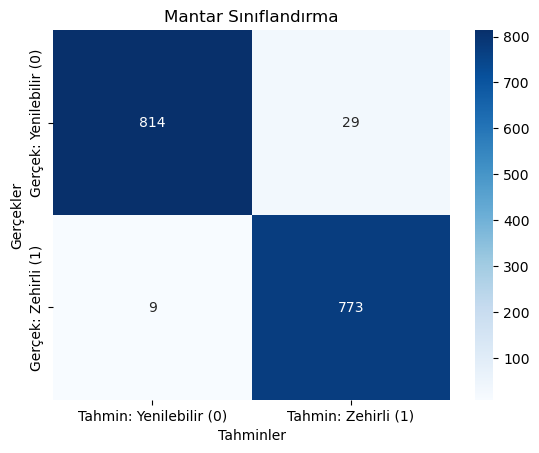

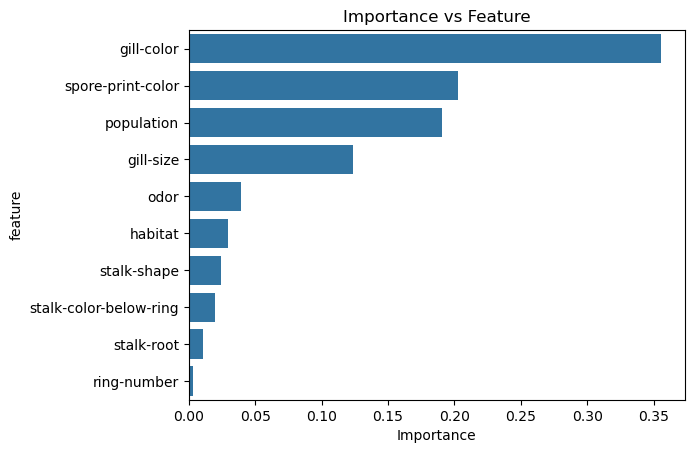

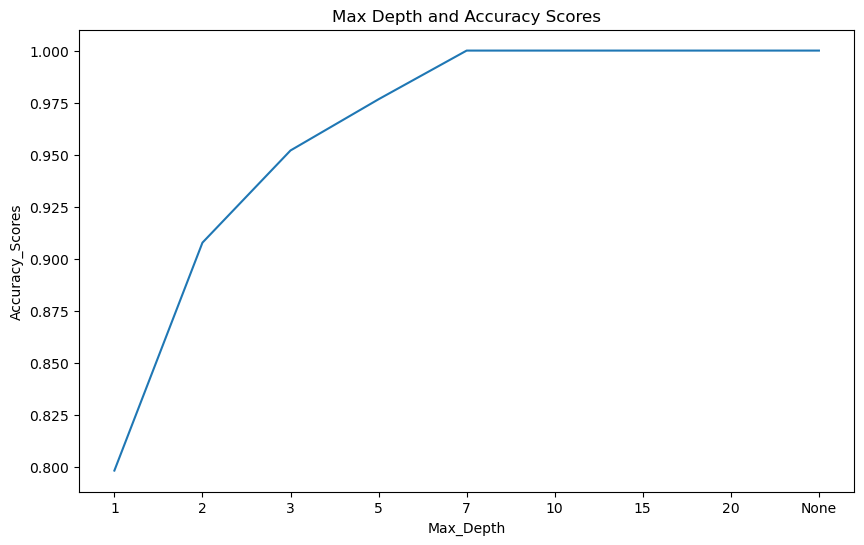

In [12]:
if __name__=="__main__":
    df=load_data("mushrooms.csv")
    df=encode_data(df)
    X_train, X_test, y_train, y_test=split_data(df)
    my_dtree=build_model(X_train, y_train)
    my_rf_tree=build_rf_model(X_train, y_train)
    y_pred=evaluate_model(my_dtree, X_test, y_test)
    y_pred2=evaluate_model(my_rf_tree, X_test, y_test)
    plot_confusion_matrix(y_test, y_pred)
    plot_feature_importance(my_dtree, X_train)
    accuracy_skorlari=compare_max_depth(X_train, y_train, X_test, y_test)
    plot_depth_comparison(accuracy_skorlari)